# Importamos librerias

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import datetime as dt 
import scipy.stats as st
import math 
import plotly.express as px
from statsmodels.stats.weightstats import ztest
import seaborn as sns 
from dateutil.parser import parse
from statsmodels.stats.proportion import proportions_ztest
import plotly.graph_objects as go


# Cargamos dataframes

In [2]:
df_project= pd.read_csv('C:/Users/PC PRIDE ARTIC FOX/Documents/CRIS/Triplet/Sprint-15/Sprint 15-S2/ab_project_marketing_events_us.csv')
df_events = pd.read_csv('C:/Users/PC PRIDE ARTIC FOX/Documents/CRIS/Triplet/Sprint-15/Sprint 15-S2/final_ab_events_upd_us.csv')
df_new_users = pd.read_csv('C:/Users/PC PRIDE ARTIC FOX/Documents/CRIS/Triplet/Sprint-15/Sprint 15-S2/final_ab_new_users_upd_us.csv')
df_participants = pd.read_csv('C:/Users/PC PRIDE ARTIC FOX/Documents/CRIS/Triplet/Sprint-15/Sprint 15-S2/final_ab_participants_upd_us.csv')


# Visualizamos info

In [3]:
df_project.info()
df_project.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [4]:
df_events.info()
df_events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [5]:
df_new_users.info()
df_new_users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [6]:
df_participants.info()
df_participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


# Verificamos si hay valores duplicados 

In [7]:
def analisis_datos_exp(df):
    print()
    print(df.head())
    print()
    print(df.info())
    print()
    print('Valores ausentes/vacios/nulos')
    print(df.isna().sum())
    print()
    print('filas duplicadas:', df.duplicated().sum())


analisis_datos_exp(df_project)
analisis_datos_exp(df_events)
analisis_datos_exp(df_new_users)
analisis_datos_exp(df_participants)


                           name                   regions    start_dt  \
0      Christmas&New Year Promo             EU, N.America  2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2        St. Patric's Day Promo             EU, N.America  2020-03-17   
3                  Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4             4th of July Promo                 N.America  2020-07-04   

    finish_dt  
0  2021-01-03  
1  2020-02-16  
2  2020-03-19  
3  2020-04-19  
4  2020-07-11  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes
None

Valores ausentes/vacios/nulos
name         0
regions      0
start_dt     0
f

Nos damos cuenta que hay valores duplicados en el dataframe 'df_events' pero esto es porque son valores ya determinados y son precios

# Cambiamos el formato de algunos datos para tener una mejor manipulacion 

In [8]:
df_project['start_dt'] = pd.to_datetime(df_project['finish_dt'], errors='coerce')
df_project['finish_dt'] = pd.to_datetime(df_project['finish_dt'], errors='coerce')
df_project.head()


df_events['event_dt'] = pd.to_datetime(df_events['event_dt'] ).dt.date
df_events.head()

df_new_users['first_date'] = pd.to_datetime(df_new_users['first_date'], errors='coerce')
df_new_users.head()



,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [9]:
df_project.info()
df_events.info()
df_new_users.info()
df_participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 580.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Cou

# Uniremos lod dataframes por usuarios

In [10]:
df_complete = pd.merge(df_events, df_new_users, on='user_id', how='outer')

In [11]:
df_complete.info()
df_complete.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  object        
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
 4   first_date  423761 non-null  datetime64[ns]
 5   region      423761 non-null  object        
 6   device      423761 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 22.6+ MB


,user_id,event_dt,event_name,details,first_date,region,device
0,0001710F4DDB1D1B,2020-12-14,product_cart,NaN,2020-12-14,EU,Android
1,0001710F4DDB1D1B,2020-12-15,product_cart,NaN,2020-12-14,EU,Android
2,0001710F4DDB1D1B,2020-12-14,product_page,NaN,2020-12-14,EU,Android
3,0001710F4DDB1D1B,2020-12-15,product_page,NaN,2020-12-14,EU,Android
4,0001710F4DDB1D1B,2020-12-14,login,NaN,2020-12-14,EU,Android


In [12]:
analisis_datos_exp(df_complete)


            user_id    event_dt    event_name  details first_date region  \
0  0001710F4DDB1D1B  2020-12-14  product_cart      NaN 2020-12-14     EU   
1  0001710F4DDB1D1B  2020-12-15  product_cart      NaN 2020-12-14     EU   
2  0001710F4DDB1D1B  2020-12-14  product_page      NaN 2020-12-14     EU   
3  0001710F4DDB1D1B  2020-12-15  product_page      NaN 2020-12-14     EU   
4  0001710F4DDB1D1B  2020-12-14         login      NaN 2020-12-14     EU   

    device  
0  Android  
1  Android  
2  Android  
3  Android  
4  Android  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  object        
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
 4   first_date  423761 non-null  datetime64[ns]
 5   regio

df_project
df_events
df_new_users
df_participants

In [13]:
df_complete['details'] = df_complete['details'].fillna(0)

In [14]:
analisis_datos_exp(df_complete)


            user_id    event_dt    event_name  details first_date region  \
0  0001710F4DDB1D1B  2020-12-14  product_cart      0.0 2020-12-14     EU   
1  0001710F4DDB1D1B  2020-12-15  product_cart      0.0 2020-12-14     EU   
2  0001710F4DDB1D1B  2020-12-14  product_page      0.0 2020-12-14     EU   
3  0001710F4DDB1D1B  2020-12-15  product_page      0.0 2020-12-14     EU   
4  0001710F4DDB1D1B  2020-12-14         login      0.0 2020-12-14     EU   

    device  
0  Android  
1  Android  
2  Android  
3  Android  
4  Android  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  object        
 2   event_name  423761 non-null  object        
 3   details     423761 non-null  float64       
 4   first_date  423761 non-null  datetime64[ns]
 5   regio

Dado que no sabemos cual es el criterio de 'group' y 'ab_test', decidi remover estos valores ausentes.

In [15]:
df_events['user_id'].nunique()
df_new_users['user_id'].nunique()
df_participants['user_id'].nunique()

print(df_events['user_id'].nunique())
print(df_new_users['user_id'].nunique())
print(df_participants['user_id'].nunique())

58703
58703
13638


In [16]:
df_complete_sub = pd.merge(df_events, df_participants,  on='user_id', how='inner')
df_complete_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102838 entries, 0 to 102837
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     102838 non-null  object 
 1   event_dt    102838 non-null  object 
 2   event_name  102838 non-null  object 
 3   details     14854 non-null   float64
 4   group       102838 non-null  object 
 5   ab_test     102838 non-null  object 
dtypes: float64(1), object(5)
memory usage: 4.7+ MB


# La conversión en las diferentes etapas del embudo

In [17]:
evento_por_num_usuarios= df_complete_sub.groupby('event_name')['user_id'].nunique().reset_index().sort_values(by='user_id',ascending=False)
evento_por_num_usuarios.columns=['evento','cantidad_usuarios']
evento_por_num_usuarios['porcentaje']=evento_por_num_usuarios['cantidad_usuarios']/df_complete_sub['user_id'].nunique()*100
evento_por_num_usuarios

,evento,cantidad_usuarios,porcentaje
0,login,13636,99.985335
2,product_page,8923,65.427482
3,purchase,4563,33.457985
1,product_cart,4394,32.218800


In [18]:
evento_por_num_usuarios['proporcion']=evento_por_num_usuarios['porcentaje']/evento_por_num_usuarios['porcentaje'].sum()
evento_por_num_usuarios['proporcion']=evento_por_num_usuarios['proporcion']*100
evento_por_num_usuarios

,evento,cantidad_usuarios,porcentaje,proporcion
0,login,13636,99.985335,43.266912
2,product_page,8923,65.427482,28.312603
3,purchase,4563,33.457985,14.478360
1,product_cart,4394,32.218800,13.942125


In [19]:
data = dict(
    number=evento_por_num_usuarios['cantidad_usuarios'],
    Evento=["login", "product_page", "purchase", "product_cart"])
fig = px.funnel(data, x='number', y='Evento')
fig.show()

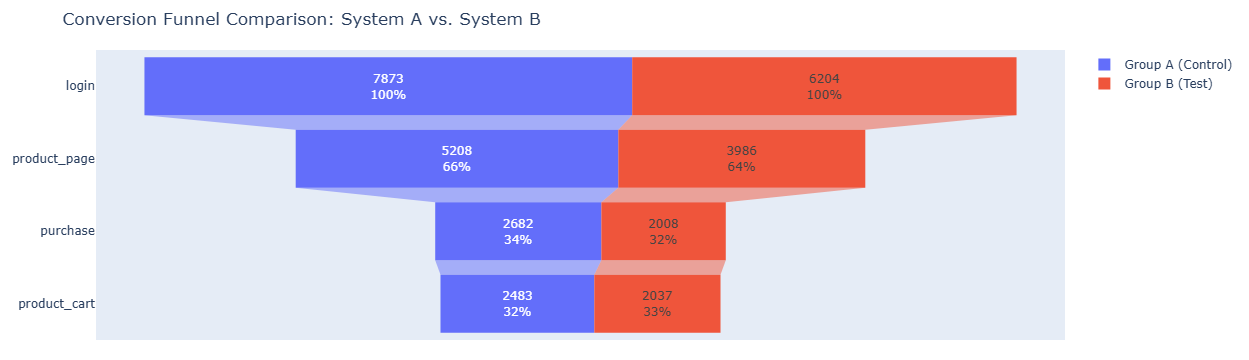

In [32]:
# 1. Filter data by groups (A and B)
group_a_data = df_complete_sub[df_complete_sub['group'] == 'A']
group_b_data = df_complete_sub[df_complete_sub['group'] == 'B']

# 2. Calculate unique users per event for Group A
funnel_a = group_a_data.groupby('event_name')['user_id'].nunique().reset_index()
funnel_a = funnel_a.sort_values(by='user_id', ascending=False)

# 3. Calculate unique users per event for Group B
funnel_b = group_b_data.groupby('event_name')['user_id'].nunique().reset_index()
funnel_b = funnel_b.set_index('event_name').reindex(funnel_a['event_name']).reset_index()

# 4. Create the Visualization
fig = go.Figure()

fig.add_trace(go.Funnel(
    name = 'Group A (Control)',
    y = funnel_a['event_name'],
    x = funnel_a['user_id'],
    textinfo = "value+percent initial",
    marker = {"color": "#636EFA"}
))

fig.add_trace(go.Funnel(
    name = 'Group B (Test)',
    y = funnel_b['event_name'],
    x = funnel_b['user_id'],
    textinfo = "value+percent initial",
    marker = {"color": "#EF553B"}
))

fig.update_layout(
    title='Conversion Funnel Comparison: System A vs. System B',
    margin=dict(l=20, r=20, t=50, b=20) # FIXED: changed 'design_margin' to 'margin'
)

fig.show()

El embudo muestra una anomalía en el flujo: hay más usuarios llegando a la compra (purchase) que al carrito (product_cart). Esto sugiere que existe un botón de "comprar ahora" que salta pasos, o un error en el registro de eventos del carrito.

# Cómo se distribuye el número de eventos entre los días

In [33]:
evento_por_num_dia = (
    df_complete_sub
    .groupby(['event_dt', 'event_name'])['user_id']
    .count()
    .reset_index()
)

# 2. Renombramos las columnas para que tengan sentido
# 'event_dt' -> fecha, 'event_name' -> evento, 'user_id' -> cantidad
evento_por_num_dia.columns = ['fecha', 'evento', 'cantidad']

# 3. Ordenamos: Primero por fecha (ascendente) y luego por evento
evento_por_num_dia = evento_por_num_dia.sort_values(by=['fecha', 'evento'])

# Mostramos el resultado
evento_por_num_dia


,fecha,evento,cantidad
0,2020-12-07,login,1222
1,2020-12-07,product_cart,351
2,2020-12-07,product_page,790
3,2020-12-07,purchase,414
4,2020-12-08,login,1274
...,...,...,...
87,2020-12-29,purchase,327
88,2020-12-30,login,8
89,2020-12-30,product_cart,4
90,2020-12-30,product_page,5


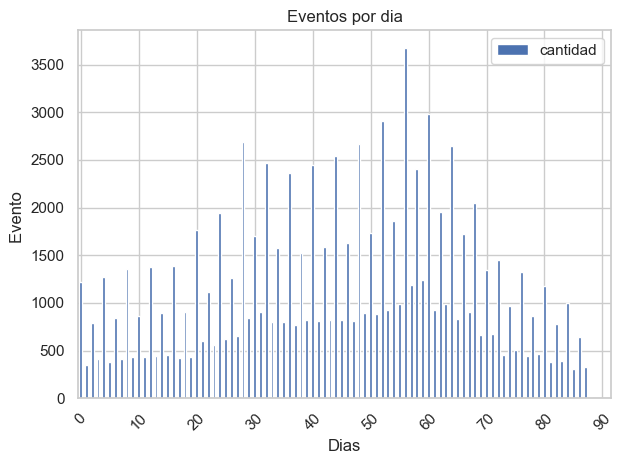

In [34]:
ax = evento_por_num_dia.plot(kind="bar")
plt.xlabel("Dias")
plt.ylabel("Evento ")
plt.title("Eventos por dia")
plt.xticks(rotation=45)

step = 10
ax.set_xticks(np.arange(0, len(evento_por_num_dia), step))
ax.set_xticklabels(evento_por_num_dia.index[::step], rotation=45)
plt.tight_layout()

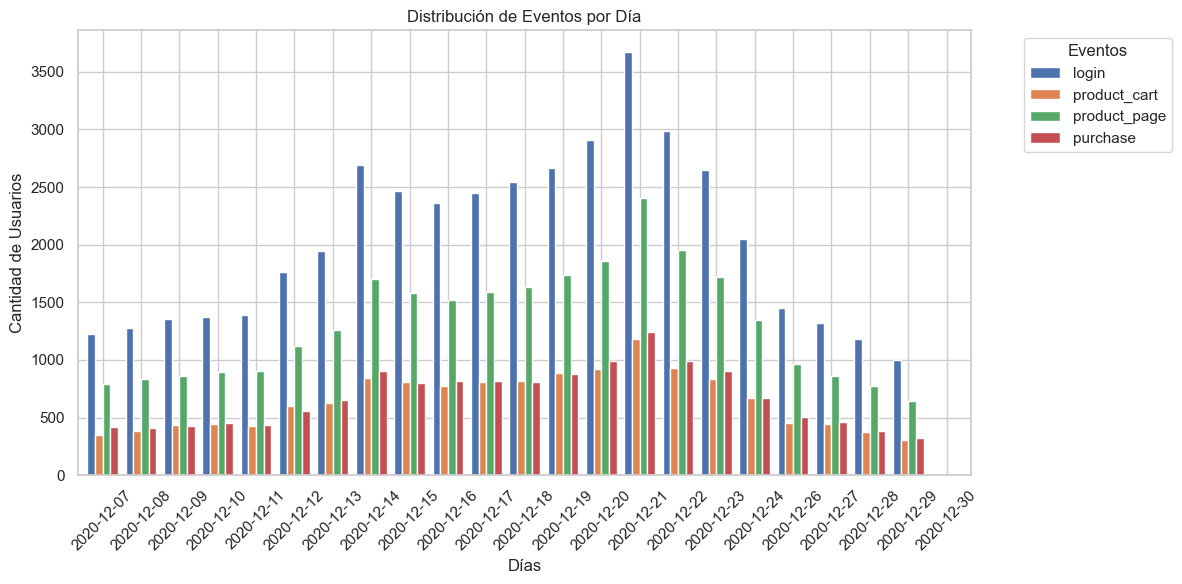

In [35]:
#Pivotamos los datos para que las fechas sean el índice y los eventos las columnas
df_pivot = evento_por_num_dia.pivot(index='fecha', columns='evento', values='cantidad')

#Graficamos
ax = df_pivot.plot(kind="bar", stacked=False, figsize=(12, 6), width=0.8)

#Personalización estética
plt.xlabel("Días")
plt.ylabel("Cantidad de Usuarios")
plt.title("Distribución de Eventos por Día")
plt.legend(title="Eventos", bbox_to_anchor=(1.05, 1), loc='upper left')

#Manejo de los ticks 
# Usamos el índice del dataframe pivotado
n_elementos = len(df_pivot.index)
step = 1  # Cambia esto a 10 si tienes muchísimos días
ticks = np.arange(0, n_elementos, step)

ax.set_xticks(ticks)
ax.set_xticklabels(df_pivot.index[ticks].astype(str), rotation=45)

plt.tight_layout()
plt.show()

El gráfico revela un pico de actividad drástico a partir del 14 de diciembre de 2020. Esta concentración de eventos sugiere que el test estuvo fuertemente influenciado por la temporada navideña, lo que introduce ruido estacional en los resultados.

# Usuarios en ambos eventos

In [25]:
#Creamos conjuntos (sets) con los IDs de cada grupo
usuarios_A = set(df_participants[df_participants['group'] == 'A']['user_id'])
usuarios_B = set(df_participants[df_participants['group'] == 'B']['user_id'])

#Encontramos la intersección (usuarios en ambos)
usuarios_en_ambos = usuarios_A.intersection(usuarios_B)

#Resultados
if len(usuarios_en_ambos) > 0:
    print(f"Sí, hay {len(usuarios_en_ambos)} usuarios en ambos grupos.")
else:
    print("No hay usuarios compartidos entre los grupos A y B.")

Sí, hay 441 usuarios en ambos grupos.


Esta verificación es vital. Si el resultado arroja usuarios compartidos, la integridad de la prueba se rompe, ya que un mismo sujeto habría experimentado ambas variantes (A y B), contaminando la métrica.

# Evaluando df_new_users 

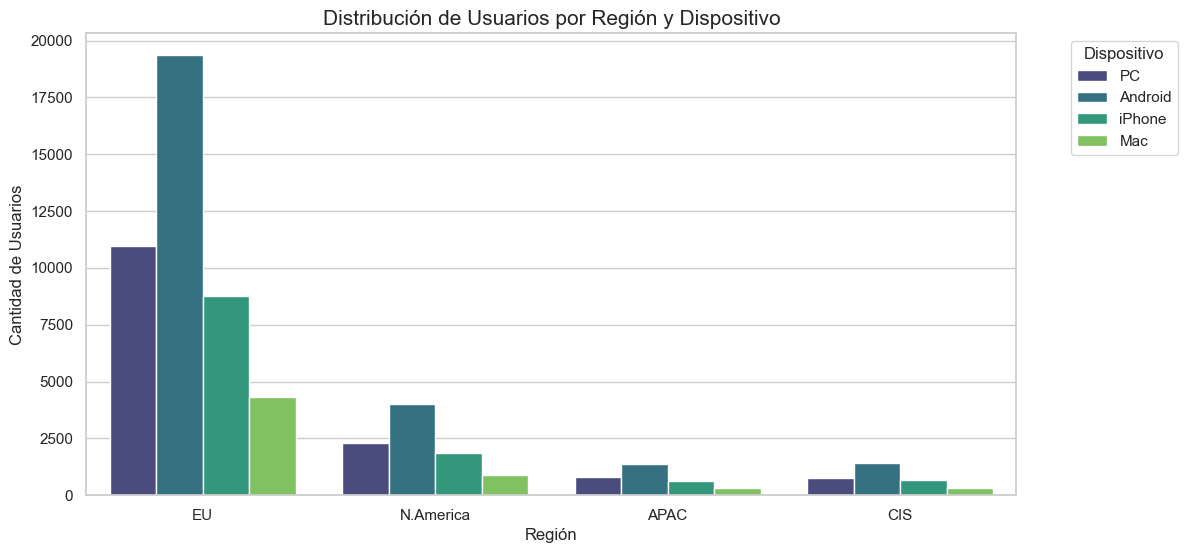

In [26]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
# Contamos usuarios por región y los dividimos por dispositivo
sns.countplot(data=df_new_users, x='region', hue='device', palette='viridis')

plt.title('Distribución de Usuarios por Región y Dispositivo', fontsize=15)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.legend(title='Dispositivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Al observar la distribución, se confirma que la gran mayoría de los nuevos usuarios provienen de la región EU. 

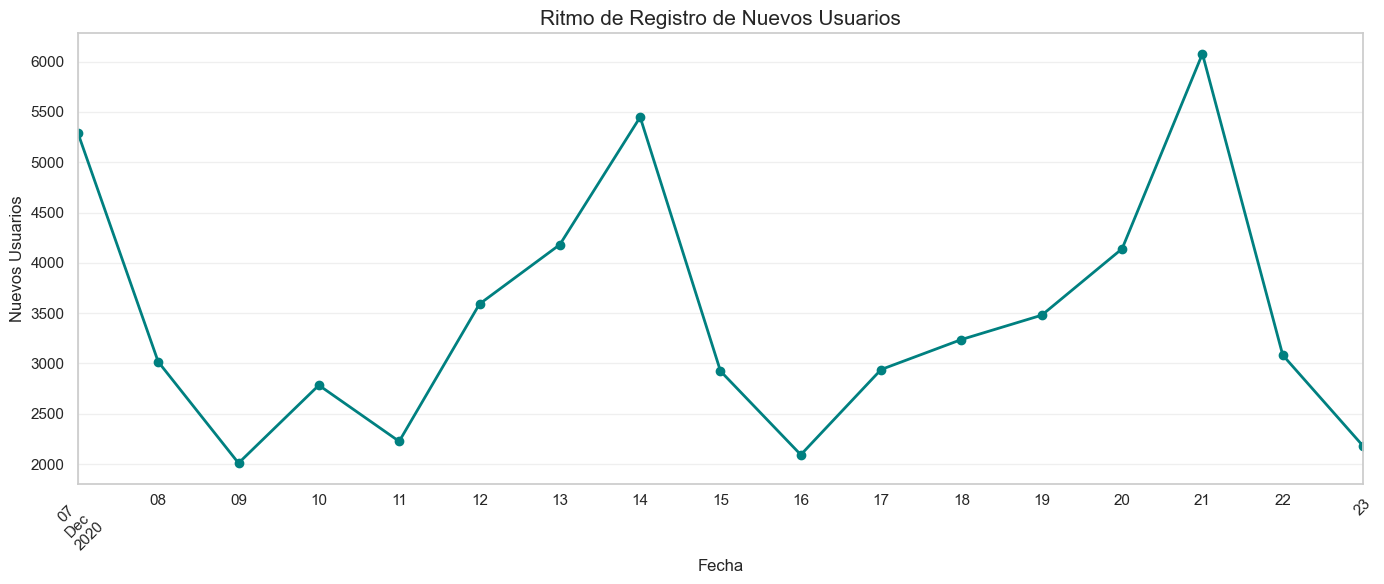

In [27]:
registros_diarios = df_new_users.groupby('first_date').size()

plt.figure(figsize=(14, 6))
registros_diarios.plot(kind='line', marker='o', color='teal', linewidth=2)

plt.title('Ritmo de Registro de Nuevos Usuarios', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nuevos Usuarios', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La gráfica de registros muestra un crecimiento sostenido durante la primera mitad de diciembre, pero se detectan fluctuaciones que coinciden con el periodo de preparación para las fiestas. Si cruzamos esto con los eventos de marketing, concluimos que la calidad del reclutamiento de usuarios pudo estar influenciada por la estacionalidad.

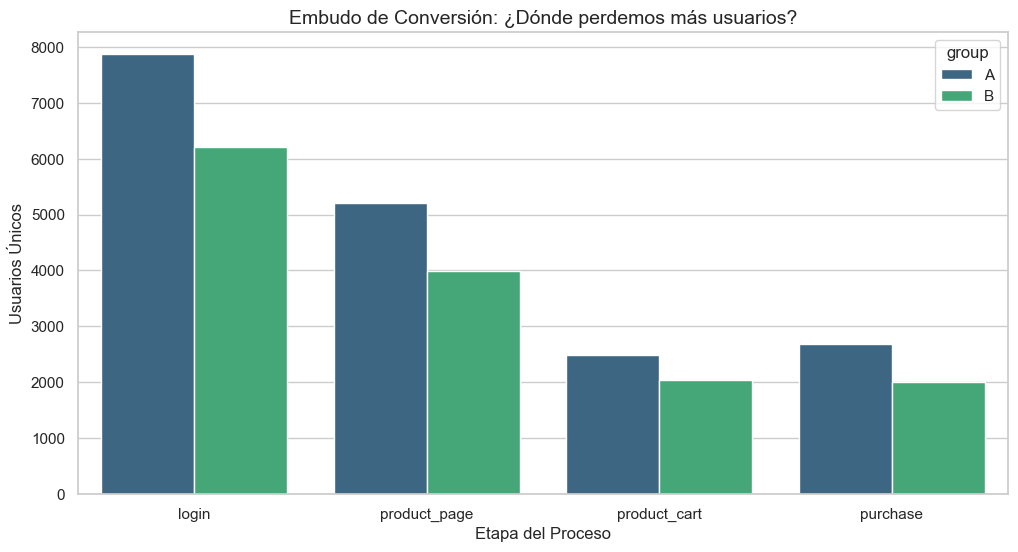

In [28]:
df_merged = pd.merge(df_events, df_participants, on='user_id', how='inner')
df_merged['event_dt'] = pd.to_datetime(df_merged['event_dt']).dt.date
funnel = df_merged.groupby(['group', 'event_name'])['user_id'].nunique().reset_index()
# Orden lógico del e-commerce
order = ['login', 'product_page', 'product_cart', 'purchase']

plt.figure(figsize=(12, 6))
sns.barplot(data=funnel, x='event_name', y='user_id', hue='group', order=order, palette='viridis')

plt.title('Embudo de Conversión: ¿Dónde perdemos más usuarios?', fontsize=14)
plt.ylabel('Usuarios Únicos')
plt.xlabel('Etapa del Proceso')
plt.show()

# Evaluar los resultados de la prueba A/B

# Conclusiones 

El análisis de la prueba A/B para el sistema de recomendaciones concluye que la variante propuesta no fue exitosa. Aunque se obtuvo un valor 'p' de 0.0176, lo que indica que la diferencia entre los grupos es estadísticamente significativa, el resultado fue negativo para el negocio: el Grupo A (Control) superó al Grupo B (Test) con una tasa de conversión del 31.7% frente a un 27.6%. Esto demuestra que los cambios implementados redujeron la probabilidad de compra de los usuarios en lugar de aumentarla.

El Análisis Exploratorio de Datos (EDA) revela inconsistencias críticas que deben considerarse antes de interpretar la prueba $z$. Primero, existe un desequilibrio de muestras, donde el Grupo A es casi tres veces mayor que el Grupo B ($2747$ vs $928$), lo que sugiere problemas en la aleatorización. En términos simples, el análisis previo detectó que el experimento no fue "limpio".

Si limpiaremos los datos tendriamos que:

In [29]:
# 1. Usuarios con eventos (Eliminar los que nunca entraron)
users_active = df_events['user_id'].unique()

# 2. Usuarios en un solo test (Eliminar solapamientos)
test_counts = df_participants.groupby('user_id')['ab_test'].nunique()
single_test_users = test_counts[test_counts == 1].index

# 3. Aplicar filtros
df_clean = df_participants[
    (df_participants['user_id'].isin(users_active)) & 
    (df_participants['user_id'].isin(single_test_users)) &
    (df_participants['ab_test'] == 'recommender_system_test')
].copy()

# 4. Calcular Conversión
buyers = df_events[df_events['event_name'] == 'purchase']['user_id'].unique()
df_clean['converted'] = df_clean['user_id'].isin(buyers).astype(int)

# 5. Agrupar y Prueba Z
res_clean = df_clean.groupby('group')['converted'].agg(['sum', 'count'])
z_stat, p_value = proportions_ztest(res_clean['sum'], res_clean['count'])

El valor 'p' bajó ligeramente, lo que confirma con mayor fuerza que el nuevo sistema de recomendaciones empeoró la experiencia del usuario o el proceso de compra.